In [1]:
# -*- coding: utf-8 -*-
from pathlib import Path
import os
import pandas as pd
import numpy as np
import keras
from tensorflow.keras.models import Model
import tensorflow as tf
import numpy as np
import cv2
from astropy.io import fits
from astropy.convolution import convolve, Box1DKernel
import statistics
import matplotlib.pyplot as plt
import joblib

import sys
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../src'))
import src.features.build_features as bfs
import src.visualization.visualize as vsz


project_dir =  Path(globals()['_dh'][0]).parent

current_dir =  Path(globals()['_dh'][0])
try:
    os.mkdir(os.path.join(current_dir, 'report_folder'))
except:
    print("Failed to create folder. Perhaps the folder already exists, or there's a permissions issue.")

Failed to create folder. Perhaps the folder already exists, or there's a permissions issue.


In [2]:
# Load desired model for prediction and class map activation

model = keras.models.load_model(os.path.join(project_dir, r'models\best_model_originalUpdate.h5'))
dom_rf_model = joblib.load(os.path.join(project_dir, r'models\rf_best_model.joblib'))

# we define a gradCAM class for loading the model and generating the heatmap.

class GradCAM:
    def __init__(self, model, classIdx, layerName=None):
        # store the model, the class index used to measure the class
        # activation map, and the layer to be used when visualizing
        # the class activation map
        self.model = model
        self.classIdx = classIdx
        self.layerName = layerName
        # if the layer name is None, attempt to automatically find
        # the target output layer
        if self.layerName is None:
            self.layerName = self.find_target_layer()


    def find_target_layer(self):
        # attempt to find the final convolutional layer in the network
        # by looping over the layers of the network in reverse order
        for layer in reversed(self.model.layers):
            # check to see if the layer has a 3D output
            if len(layer.output_shape) == 3:
                return layer.name
        # otherwise, we could not find a 4D layer so the GradCAM
        # algorithm cannot be applied
        raise ValueError("Could not find 3D layer. Cannot apply GradCAM.")


    def compute_heatmap(self, flux, eps=1e-8):
        # construct our gradient model by supplying (1) the inputs
        # to our pre-trained model, (2) the output of the (presumably)
        # final 3D layer in the network, and (3) the output of the
        # softmax activations from the model
        gradModel = Model(
            inputs=[self.model.inputs],
            outputs=[self.model.get_layer(self.layerName).output,
                     self.model.output])

        # record operations for automatic differentiation
        with tf.GradientTape() as tape:
            # cast the flux tensor to a float-32 data type, pass the
            # flux through the gradient model, and grab the loss
            # associated with the specific class index
            inputs = tf.cast(flux, tf.float32)
            (convOutputs, predictions) = gradModel(inputs)
            loss = predictions[:, self.classIdx]
        # use automatic differentiation to compute the gradients
        grads = tape.gradient(loss, convOutputs)

        # compute the guided gradients
        castConvOutputs = tf.cast(convOutputs > 0, "float32")
        castGrads = tf.cast(grads > 0, "float32")
        guidedGrads = castConvOutputs * castGrads * grads
        # the convolution and guided gradients have a batch dimension
        # (which we don't need) so let's grab the volume itself and
        # discard the batch
        convOutputs = convOutputs[0]
        guidedGrads = guidedGrads[0]

        # compute the average of the gradient values, and using them
        # as weights, compute the ponderation of the filters with
        # respect to the weights
        weights = tf.reduce_mean(guidedGrads, axis=(0, 1))
        cam = tf.reduce_sum(tf.multiply(weights, convOutputs), axis=-1)

        # grab the spatial dimensions of the input image and resize
        # the output class activation map to match the input image
        # dimensions
        (w, h) = (flux.shape[2], flux.shape[1])
        heatmap = cv2.resize(cam.numpy(), (w, h))
        # normalize the heatmap such that all values lie in the range
        # [0, 1], scale the resulting values to the range [0, 255],
        # and then convert to an unsigned 8-bit integer
        numer = heatmap - np.min(heatmap)
        denom = (heatmap.max() - heatmap.min()) + eps
        heatmap = numer / denom
        heatmap = (heatmap * 255).astype("uint8")
        # return the resulting heatmap to the calling function
        return heatmap

    def overlay_heatmap(self, heatmap, image, alpha=0.5,
                        colormap=cv2.COLORMAP_VIRIDIS):
        # apply the supplied color map to the heatmap and then
        # overlay the heatmap on the input image
        heatmap = cv2.applyColorMap(heatmap, colormap)
        output = cv2.addWeighted(image, alpha, heatmap, 1 - alpha, 0)
        # return a 2-tuple of the color mapped heatmap and the output,
        # overlaid image
        return (heatmap, output)

In [3]:
ohe_dict = {'WDA': np.array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]),
            'WDZ': np.array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]),
            'WDB': np.array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]),
            'WDO': np.array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]),
            'WD+MS': np.array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
            'WD': np.array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
            'sdX': np.array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
            'WDH': np.array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]),
            'WDELM': np.array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]),
            'WDC': np.array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]),
            'CV': np.array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
            'WDQ': np.array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])}

star_class = vsz.sort_ohe(ohe_dict)

In [4]:
def extraction(fits_file):
    hdu  = fits.open(fits_file)
    data = hdu['COADD'].data
    w = 10**data['loglam']
    f = data['flux']*1e-17
    return w,f

def load_spectrum_data(file_path: str):
    if file_path.endswith('fits'):
        wavelength, flux = extraction(file_path)
    elif file_path.endswith('.dat'):
        sed = np.loadtxt(file_path, unpack = True)
        wavelength = sed[0,:]
        flux = sed[1,:]
    else:
        print("what format is that?")
        return None
    
    return wavelength, flux

base_wavelenght, _ = load_spectrum_data(os.path.join(project_dir, 'calibration_dat_file.dat'))
base_wavelenght = base_wavelenght[298:-600] # this is the wavelenght axis the model was trained on.

In [5]:
# Now we can begin to process incoming data by preprocessing it.

filepath = r'data\raw\sdss_dat_files\cb_uvex1\SDSSJ000131.12+264655.1_15004-59165-0023_4402817878.dat'
w, f = load_spectrum_data(os.path.join(project_dir, filepath))
# Interpolation
flux = np.interp(base_wavelenght, w, f)
# normalization
norm_magnitud = statistics.mean(flux[2050:2100])
flux = np.divide(flux, statistics.mean(flux[2050:2100]))

In [6]:
flux.shape

(3750,)

In [7]:
dom_pred = dom_rf_model.predict(flux.reshape(1, -1) )
bool(dom_pred)

True

In [8]:
# First we get the model prediction:
prediction = model.predict(flux.reshape(1,-1,1))
predicted_class = prediction.argmax(1)

1/1 [==============================] - 0s 111ms/step


1/1 [==============================] - 0s 13ms/step


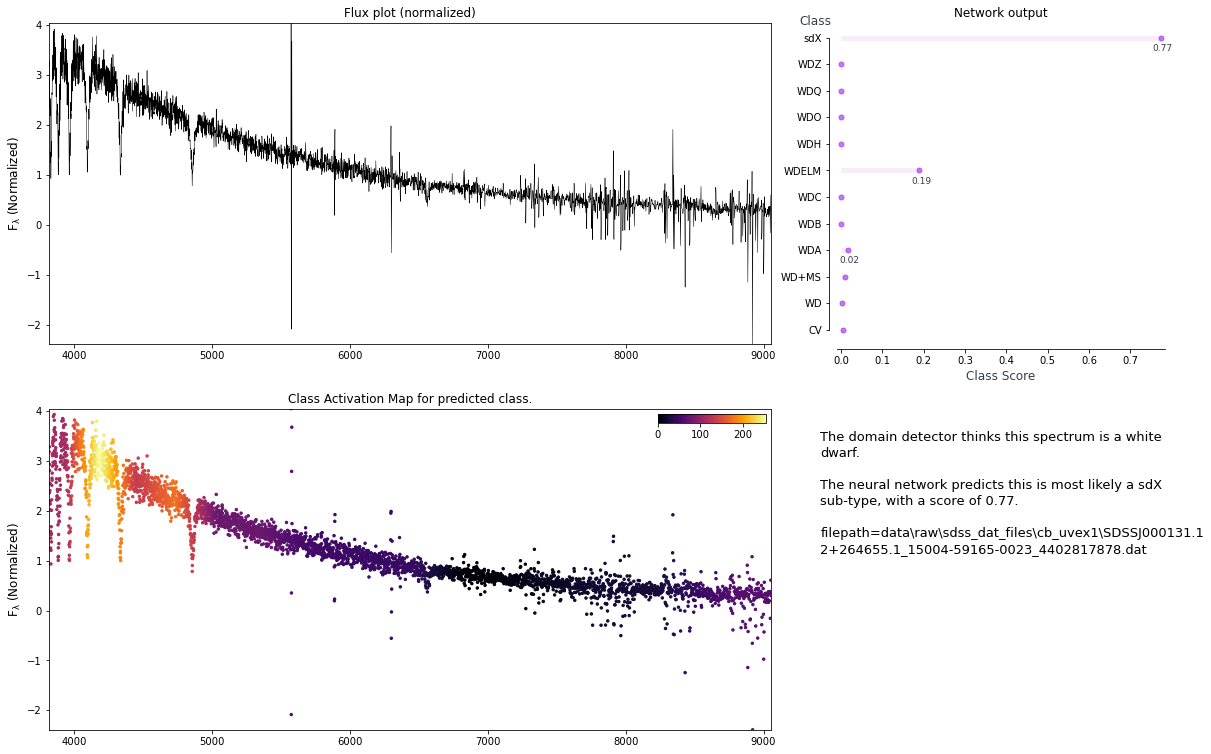

In [16]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.gridspec import GridSpec
import textwrap

fig = plt.figure(figsize=(20,13)) 

gs = GridSpec(2, 3, figure=fig)
cam_wda = GradCAM(model, int(predicted_class))
params = {'mathtext.default': 'regular' }          
plt.rcParams.update(params)

# spectrum, heatmap, activation ant text axes

spax = fig.add_subplot(gs[0, 0:2])
hmax = fig.add_subplot(gs[1, 0:2])
acax = fig.add_subplot(gs[0, 2])
tax = fig.add_subplot(gs[1, 2])

# Spectrum plot

spax.set_title('Flux plot (normalized)')
spax.plot(base_wavelenght, flux, color='black', linewidth=0.5)
spax.get_tightbbox(renderer=fig.canvas.get_renderer())
spax.set_ylabel('$F_\lambda$ (Normalized)', fontsize=12)

# Heatmap Plot

heatmap = cam_wda.compute_heatmap(flux.reshape(1,-1,1))
hmax.set_title('Class Activation Map for predicted class.')
sc = hmax.scatter(base_wavelenght, flux, c=heatmap, s=6, cmap = 'inferno')
hmax.set_ylabel('$F_\lambda$ (Normalized)', fontsize=12)
cbaxes = inset_axes(hmax, width="15%", height="3%", loc=1) 
fig.colorbar(sc, cax=cbaxes, orientation='horizontal')

### Activation plot

acax.set_title('Network output')
my_range=list(range(1,13))

preds = model.predict(flux.reshape(1,-1,1)).reshape((12,))

### Draw predictions 
acax.hlines(y=star_class, xmin=0, xmax=preds, color='#DDA0DD', alpha=0.2, linewidth=5)
acax.set_xlabel('Class Score', fontsize=12, color = '#333F4B')
acax.set_ylabel('')

# add little dots
acax.plot(preds, star_class, "o", markersize=5, color='#A020F0', alpha=0.6)

# add label for top 3 predictions
for value in sorted(preds, reverse=True)[:3]:
    acax.text(value - 0.02, int(np.where(preds == value)[0]) - 0.5, "{:.2f}".format(value), fontsize=9, color = '#333F4B')

acax.text(-0.1, 11.5, 'Class', fontsize=12, color = '#333F4B')

# change the style of the axis spines
acax.spines['top'].set_visible(False)
acax.spines['right'].set_visible(False)
acax.spines['left'].set_bounds((0, len(star_class)-1))
acax.set_xlim(-0.01,max(preds)+0.01)

# add some space between the axis and the plot
acax.spines['left'].set_position(('outward', 8))
acax.spines['bottom'].set_position(('outward', 5))

### Text box axis

value = """The domain detector thinks this spectrum {} a white dwarf. \nThe neural network predicts this is most likely a {} sub-type, with a score of {:.2f}. \nfilepath={}
""".format('is' if bool(dom_pred) else "isn't", star_class[int(np.where(preds == max(preds))[0])], max(preds), str(filepath))

# Wrap this text.
wrapper = textwrap.TextWrapper(width=55, replace_whitespace=False)
  
word_list = []  
for paragraph in value.split('\n'):
    word_list += wrapper.wrap(text=paragraph) + [' ']
# Print each line.
Delta = 0.05
for (i, element) in enumerate(word_list):
    tax.text(-0.05, 0.9 - i * Delta, element , fontsize=13 ,  transform=tax.transAxes)

tax.set_axis_off()

spax.autoscale(tight=True)
hmax.autoscale(tight=True)
# acax.autoscale(tight=True)

In [10]:
predicted_class

array([11], dtype=int64)

In [11]:
preds

array([5.84982755e-03, 2.58424366e-03, 1.02529079e-02, 1.70279890e-02,
       4.09755048e-05, 6.09133967e-05, 1.89516544e-01, 8.06675875e-04,
       9.25760659e-08, 3.79927201e-11, 1.27110025e-05, 7.73847103e-01],
      dtype=float32)

In [12]:
predicted_class

array([11], dtype=int64)

In [13]:
preds

array([5.84982755e-03, 2.58424366e-03, 1.02529079e-02, 1.70279890e-02,
       4.09755048e-05, 6.09133967e-05, 1.89516544e-01, 8.06675875e-04,
       9.25760659e-08, 3.79927201e-11, 1.27110025e-05, 7.73847103e-01],
      dtype=float32)

In [14]:
value

'The domain detector thinks this spectrum is a white dwarf. \nThe neural network predicts this is most likely a sdX sub-type, with a score of 0.77. \nfilepath=data\\raw\\sdss_dat_files\\cb_uvex1\\SDSSJ000131.12+264655.1_15004-59165-0023_4402817878.dat\n'